In [1]:
%pylab inline
import os,sys,pickle,yaml
from builtins import sum as bsum
from importlib import reload
plt.style.use('default')
os.environ["FISHER_PLUMES"] = os.path.join(os.environ["GIT"],"fisher-plumes")
os.chdir(os.environ["FISHER_PLUMES"])



Populating the interactive namespace from numpy and matplotlib


In [2]:
try:
    UNITS
except NameError:
    import units; reload(units); UNITS = units.UNITS;


In [468]:
import boulder;   reload(boulder)
import crick;     reload(crick)
import fisher_plumes_tools as fpt;      reload(fpt)
import fisher_plumes_figs as fpf;       reload(fpf)
import fisher_plumes as fp;             reload(fp)
import proc; reload(proc);
import assumptions as assm;



INFO:crick:Simulation data available for:


INFO:crick:crimgrid_w1                                     : y0 - y9 (16 datasets)


INFO:crick:crimgrid_w2                                     : y0 - y9 (16 datasets)


INFO:crick:crimgrid_w3                                     : y0 - y9 (16 datasets)


INFO:crick:crimgrid_w4                                     : y0 - y9 (16 datasets)


...

INFO:crick:n12dishT                                        : Y0.450 - Y0.550 (11 datasets)


INFO:crick:n16T                                            : Y0.440 - Y0.560 (16 datasets)


INFO:crick:n16Tslow                                        : Y0.440 - Y0.560 (16 datasets)


INFO:crick:n16Tslow_45deg                                  : X0.418Y0.458 - X0.502Y0.542 (16 datasets)


INFO:crick:n16Tslow_X                                      : X0.400 - X0.648 (32 datasets)


In [472]:
# Get the fp_data file that we want to plot
matches = proc.find_registry_matches(init_filter = {"sim_name":"boulder16", "which_coords":(0.45, 0.5) * UNITS.m},
                                     compute_filter = {"window_shape":"hann", "window_length": 1 * UNITS.s, "dmax_um":"1 * PITCH"})


                    proc 2024/07/28 19:05:17     INFO: No registry given. Loading registry from proc/registry.p.


                    proc 2024/07/28 19:05:17     INFO: Checking for x_m=0.45, y_m=0.5.


In [473]:
full_file_name = matches[0]["file"]
fp_data = pickle.load(open(full_file_name, 'rb'))["results"]
suffix = full_file_name.split("/")[-1]
print(full_file_name, suffix)


proc/bw.1/72796384e420d8ea.p 72796384e420d8ea.p


In [474]:
reload(boulder); reload(fp)
[x.logger.setLevel(logging.WARN) for x in [boulder, fp]]
F = fp.FisherPlumes(fp_data)


INFO:boulder:Boulder simulation data available for:


INFO:boulder:Re100_0_5mm_50Hz_16source_manuscript.h5         : ['Odor Data/c1a', 'Odor Data/c1b', 'Odor Data/c2a', 'Odor Data/c2b', 'Odor Data/c3a', 'Odor Data/c3b', 'Odor Data/c4a', 'Odor Data/c4b', 'Odor Data/c5a', 'Odor Data/c5b', 'Odor Data/c6a', 'Odor Data/c6b', 'Odor Data/c7a', 'Odor Data/c7b', 'Odor Data/c8a', 'Odor Data/c8b'] (16 datasets)


INFO:boulder:Re100_0_5mm_50Hz_pi4SourceSep.h5                : ['Odor Data/c1a', 'Odor Data/c2a', 'Odor Data/c3a', 'Odor Data/c4a', 'Odor Data/c5a', 'Odor Data/c6a', 'Odor Data/c7a', 'Odor Data/c8a', 'Odor Data/c9a', 'Odor Data/c10a', 'Odor Data/c11a', 'Odor Data/c12a', 'Odor Data/c13a', 'Odor Data/c14a', 'Odor Data/c15a', 'Odor Data/c16a'] (16 datasets)


INFO:boulder:Re100_0_5mm_50Hz_streamwiseSourceSep.h5         : ['Odor Data/c1a', 'Odor Data/c2a', 'Odor Data/c3a', 'Odor Data/c4a', 'Odor Data/c5a', 'Odor Data/c6a', 'Odor Data/c7a', 'Odor Data/c8a', 'Odor Data/c9a', 'Odor Data/c10a', 'Odor Data/c11a', 'Odor Data/c12a', 'Odor Data/c13a', 'Odor Data/c14a', 'Odor Data/c15a', 'Odor Data/c16a'] (16 datasets)


# Are the distributions the same from each source?

In [335]:
data_file = "proc/bw.1/test_assm/test_assm_loc_ind/" + suffix
results = pickle.load(open(data_file, 'rb'))

In [338]:
vec,ifreqs,keys = assm.LocationIndependence.results_to_vec(results["results"]["location_independence"])

<ipython-input-345-04f9655f51fb>:1: RuntimeWarning: divide by zero encountered in log10
  matshow(-log10(vec), vmin=0, vmax=3, cmap='gnuplot');


[0. 1. 2. 3.]


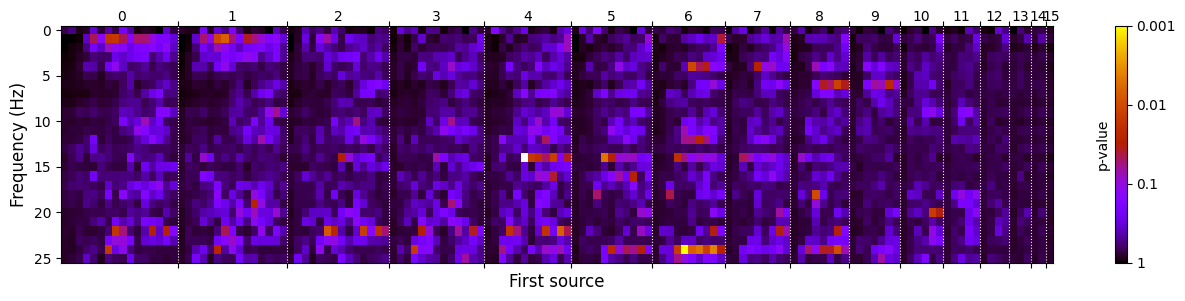

In [345]:
matshow(-log10(vec), vmin=0, vmax=3, cmap='gnuplot');
axis("auto")
src1 = np.array([k.src1 for k in keys[0]])
assert list(src1) == sorted(src1)
unique_src1 = sorted(np.unique(src1))
axis('auto')

xt_loc = np.where(np.diff(src1) > 0)[0] + 0.5
# I don't want the major ticks to be labeld, so I'll set the labels to empty strings.
xt_loc1 = np.array([0] + list(xt_loc) + [len(src1)])
midpoints = (xt_loc1[1:] + xt_loc1[:-1]) / 2
xticks(xt_loc, [""]*len(xt_loc))
for i, mid in enumerate(midpoints):
    text(mid, -1, f"{unique_src1[i]:g}", ha='center', fontsize=10)
xlabel(f"First source", fontsize=12)
# Turn the grid on, but only for the x-ticks, and using a dotted line.
grid(axis='x', linestyle=':', color='w')

yt = gca().get_yticks()
yt = yt[(0 <= yt)* (yt< len(ifreqs))]
yt_freqs = [f"{f.to(UNITS.Hz).magnitude:g}" for f in F.inds2freqs(np.array(ifreqs)[yt.astype(int)])]
yticks(yt, yt_freqs)
ylabel("Frequency (Hz)", fontsize=12)

cax = colorbar().ax
cax.set_yticks([0.,1.,2.,3.])
yt = cax.get_yticks()
print(yt)
cax.set_yticklabels([f"{10**-yti:g}" for yti in yt])
cax.set_ylabel("p-value")
# Set the position of the label to the left of the colorbar
cax.yaxis.set_label_position('left')
savefig("figs/loc_ind.png", dpi=300, bbox_inches='tight')


# Are the distributions from each source gaussian?

In [347]:
data_file = "proc/bw.1/test_assm/test_assm_gauss_coefs/" + suffix
results = pickle.load(open(data_file, 'rb'))

In [352]:
vec,ifreqs,keys = assm.GaussianCoefs.results_to_vec(results["results"]["gaussian_coefs"])

<ipython-input-375-062ce939f607>:2: RuntimeWarning: divide by zero encountered in log10
  matshow(-log10(vec), vmin=0, vmax=3, cmap='gnuplot');


[0. 1. 2. 3.]


<Figure size 800x500 with 0 Axes>

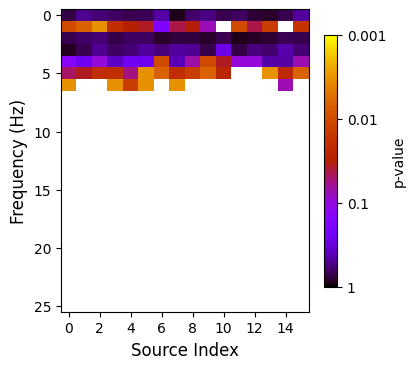

In [375]:
figure(figsize=(8,5))
matshow(-log10(vec), vmin=0, vmax=3, cmap='gnuplot');
#axis("auto")
src1 = np.array([k.src1 for k in keys[0]])
assert list(src1) == sorted(src1)
axis('auto')
gca().set_aspect(0.75)

xlabel(f"Source Index", fontsize=12)
gca().xaxis.set_ticks_position('bottom')
# Turn the grid on, but only for the x-ticks, and using a dotted line.

yt = gca().get_yticks()
yt = yt[(0 <= yt)* (yt< len(ifreqs))]
yt_freqs = [f"{f.to(UNITS.Hz).magnitude:g}" for f in F.inds2freqs(np.array(ifreqs)[yt.astype(int)])]
yticks(yt, yt_freqs)
ylabel("Frequency (Hz)", fontsize=12)

# Make a narrow colorbar 
cax = colorbar(shrink=0.5, aspect=20).ax
cax.set_yticks([0.,1.,2.,3.])
yt = cax.get_yticks()
print(yt)
cax.set_yticklabels([f"{10**-yti:g}" for yti in yt])
cax.set_ylabel("p-value")
# Set the position of the label to the left of the colorbar
savefig("figs/gauss_coefs.png", dpi=300, bbox_inches='tight')


# Are the distributions from each source stationary?

In [475]:
wc_safe = lambda x: 1 if allclose(x,0) else wilcoxon(x).pvalue

In [476]:
data_file = "proc/bw.1/test_assm/test_assm_stationarity/" + suffix
results = pickle.load(open(data_file, 'rb'))

In [420]:
vec,ifreqs,keys = assm.Stationarity.results_to_vec(results["results"]["stationarity"])

In [441]:
vals = vec.copy()
for i in range(vals.shape[0]):
    vals[i][:,-1] = wc_safe(vec[i,:,-1])

In [445]:
from mpl_toolkits.axes_grid1 import make_axes_locatable

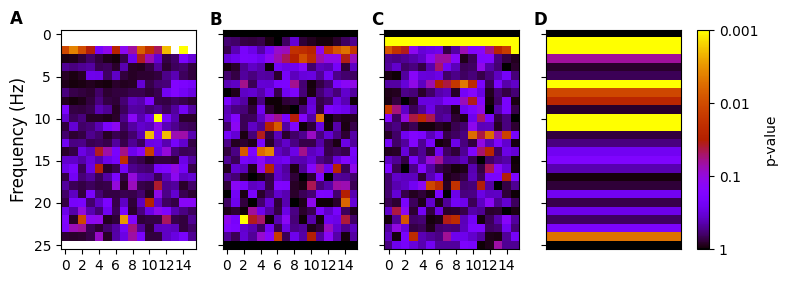

In [466]:
figure(figsize=(8,5))
ax = []
for i in range(4):
    ax.append(subplot(1,4,i+1))
    v = vals[:,:,i].copy()
    v[v == 0] = nan
    matshow(-log10(v),vmin=0,vmax=3,fignum=False, cmap='gnuplot')
    i > 0 and setp(ax[-1].get_yticklabels(), visible=False)
    i == 3 and ax[-1].set_xticks([])
    ax[-1].xaxis.set_ticks_position('bottom')

yt = ax[0].get_yticks()
yt = yt[(0 <= yt)* (yt< len(ifreqs))]
yt_freqs = [f"{f.to(UNITS.Hz).magnitude:g}" for f in F.inds2freqs(np.array(ifreqs)[yt.astype(int)])]
ax[0].set_yticks(yt, yt_freqs)
ax[0].set_ylabel("Frequency (Hz)", fontsize=12)    
# Get the position of the last axis
pos = ax[-1].get_position()
# Create a new axis for the colorbar
cax = gcf().add_axes([pos.x1 + 0.02, pos.y0, 0.015, pos.height])
# Append a new axis for the colorbar with a specified width
colorbar(cax=cax).set_label("p-value")
cax.set_yticks([0.,1.,2.,3.])
cax.set_yticklabels([f"{10**-yti:g}" for yti in cax.get_yticks()])
fpft.label_axes(ax, "ABCD", fontweight='bold', fontsize=12, dy=0.01,dx=[0]+[-0.01]*3)
    

In [467]:
savefig("figs/stationarity.png", dpi=300, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

# Checking whether joint distributions only depend on the distance between sources.

In [62]:
data_file = "proc/bw.1/test_assm/test_assm_joint_dist/" + suffix
results = pickle.load(open(data_file, 'rb'))


0.3, 0.6, 0.9, 1.2, 1.5, 1.8, 2.1, 2.4, 2.7, 3, 3.3, 3.6, 3.9, 4.2, [0. 1. 2. 3.]


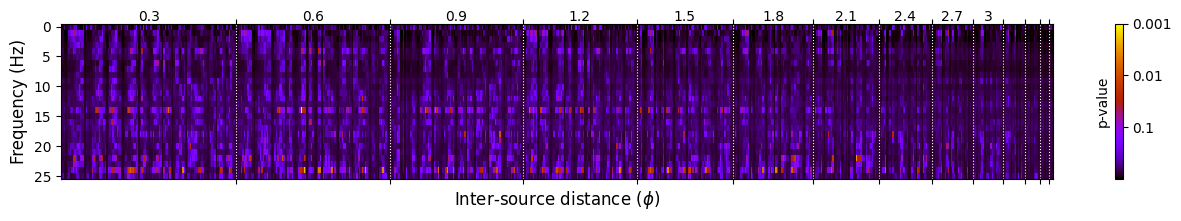

In [164]:
vec,ifreqs,keys = assm.JointDist.results_to_vec(results["results"]["joint_dist"])
dists = np.array([k.dist for k in keys[0]])
assert list(dists) == sorted(dists)
unique_dists = sorted(np.unique(dists))
vals = vec.reshape((-1, len(dists)))
vals[vals == 0] = np.nan
matshow(-log10(vals), cmap='gnuplot');
axis('auto')
yt = gca().get_yticks()
valid_yt = [int(yti) for yti in yt if yti in ifreqs]
freqs = F.inds2freqs(valid_yt)
yticks(valid_yt, [f"{f.to(UNITS.Hz).magnitude:g}" for f in freqs])
ylabel("Frequency (Hz)", fontsize=12)
# Each column is a pair of sources being compared.
# These will be in blocks sorted by the distance between the sources.
# So e.g. the first N_1 columns will be at the  minimum distance, the next N_2 columns will be at the next largest distance, etc.
# I want major ticks to be at the start of each block.
xt_loc = np.where(np.diff(dists) > 0)[0] + 0.5
# I don't want the major ticks to be labeld, so I'll set the labels to empty strings.
xt_loc1 = np.array([0] + list(xt_loc) + [len(dists)])
midpoints = (xt_loc1[1:] + xt_loc1[:-1]) / 2
xticks(xt_loc, [""]*len(xt_loc))
for i, mid in enumerate(midpoints):
    dist_um = unique_dists[i]
    dist_pitch = (dist_um * UNITS.um).to(F.pitch).magnitude
    print(f"{dist_pitch:g}", end = ", ")
    (dist_pitch < 3.1) and text(mid, -1, f"{dist_pitch:g}", ha='center', fontsize=10 if dist_pitch <= 3.4 else 6)
xlabel(f"Inter-source distance ({fpf.pitch_sym})", fontsize=12)
# Turn the grid on, but only for the x-ticks, and using a dotted line.
grid(axis='x', linestyle=':', color='w')

cax = colorbar().ax
yt = cax.get_yticks()
print(yt)
cax.set_yticklabels([f"{10**-yti:g}" for yti in yt])
cax.set_ylabel("p-value")
# Set the position of the label to the left of the colorbar
cax.yaxis.set_label_position('left')
savefig("figs/joint_dist.png", dpi=300, bbox_inches='tight')

# Checking whether the conditional distribution of coefficients is Gaussian

In [286]:
data_file = "proc/bw.1/test_assm/test_assm_cond_gauss/" + suffix
results = pickle.load(open(data_file, 'rb'))
spec = utils.load_yaml(results["test_assm_spec"])
vec,ifreqs,keys,bad_keys = assm.ConditionalGaussian.results_to_vec(results["results"]["cond_gauss"], n_bins = spec["cond_gauss"]["n_bins"],n_trials = spec["cond_gauss"]["n_trials"], min_count_per_bin = 10)


             assumptions 2024/07/28 15:26:29     INFO: Nan'd 136 keys due to missing or incomplete data.


In [298]:
vec_m = np.nanmean(np.nanmean(vec, axis=-1),axis=-1);

<ipython-input-298-15162faecd5f>:1: RuntimeWarning: Mean of empty slice
  vec_m = np.nanmean(np.nanmean(vec, axis=-1),axis=-1);


[0. 1. 2. 3.]


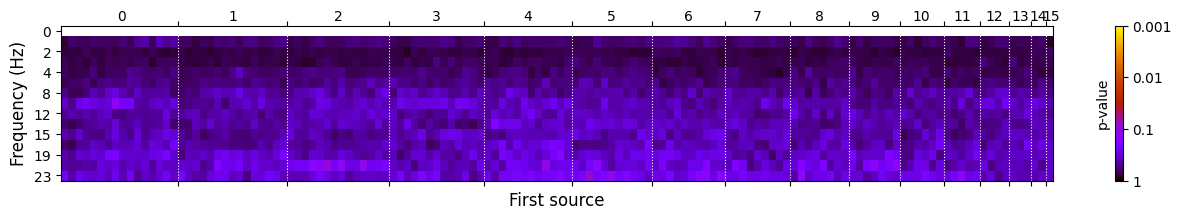

In [329]:
matshow(-log10(vec_m), vmin=0, vmax=3, cmap='gnuplot');
axis("auto")
src1 = np.array([k.src1 for k in keys[0]])
assert list(src1) == sorted(src1)
unique_src1 = sorted(np.unique(src1))
axis('auto')

xt_loc = np.where(np.diff(src1) > 0)[0] + 0.5
# I don't want the major ticks to be labeld, so I'll set the labels to empty strings.
xt_loc1 = np.array([0] + list(xt_loc) + [len(src1)])
midpoints = (xt_loc1[1:] + xt_loc1[:-1]) / 2
xticks(xt_loc, [""]*len(xt_loc))
for i, mid in enumerate(midpoints):
    text(mid, -1, f"{unique_src1[i]:g}", ha='center', fontsize=10)
xlabel(f"Conditioning source", fontsize=12)
# Turn the grid on, but only for the x-ticks, and using a dotted line.
grid(axis='x', linestyle=':', color='w')

yt = gca().get_yticks()
yt = yt[(0 <= yt)* (yt< len(ifreqs))]
yt_freqs = [f"{f.to(UNITS.Hz).magnitude:g}" for f in F.inds2freqs(np.array(ifreqs)[yt.astype(int)])]
yticks(yt, yt_freqs)
ylabel("Frequency (Hz)", fontsize=12)

cax = colorbar().ax
yt = cax.get_yticks()
print(yt)
cax.set_yticklabels([f"{10**-yti:g}" for yti in yt])
cax.set_ylabel("p-value")
# Set the position of the label to the left of the colorbar
cax.yaxis.set_label_position('left')
savefig("figs/cond_gauss.png", dpi=300, bbox_inches='tight')


# The End